In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load the original dataset
file_path = "breast-cancer.csv"
df = pd.read_csv(file_path)

#Check for missing values in the dataset
print("Checking for missing values in the dataset:")
print(df.isnull().sum())

#Check for zero values (if applicable)
print("\nChecking for zero values in the dataset:")
print((df == 0).sum())

# Drop ID because it is ireelevant to know the annonymous patients used in the sample data
df = df.drop(columns=['id'], errors='ignore')

#STEP 1
#Ensure the 'diagnosis' column is binary: 0 for Benign ('B'), 1 for Malignant ('M')
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

#Save the cleaned dataframe to a new file
updated_file_path = "breast-cancer-updated.csv"
df.to_csv(updated_file_path, index=False)

print(f"\nThe cleaned dataset has been saved to {updated_file_path}")


Checking for missing values in the dataset:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Checking for z

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
#STEP 2
# Separate features (X) and labels (y)
X = df.drop(columns=['diagnosis'])  # Features
y = df['diagnosis']  # Labels (0 = Benign, 1 = Malignant)

#Split the data into Training (60%), Validation (20%), and Test (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)  # 60% training, 40% temp
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 50% of the 40% for validation, 50% for test

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 341 samples
Validation set size: 114 samples
Test set size: 114 samples


In [6]:
#Train a Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

#Predict on Training, Validation, and Test sets
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)



Training Accuracy: 1.0000
Validation Accuracy: 0.9737
Test Accuracy: 0.9649
Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       209
           1       1.00      1.00      1.00       132

    accuracy                           1.00       341
   macro avg       1.00      1.00      1.00       341
weighted avg       1.00      1.00      1.00       341

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Test Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        76
           1       1.00      0.89      0.94        38

    accuracy

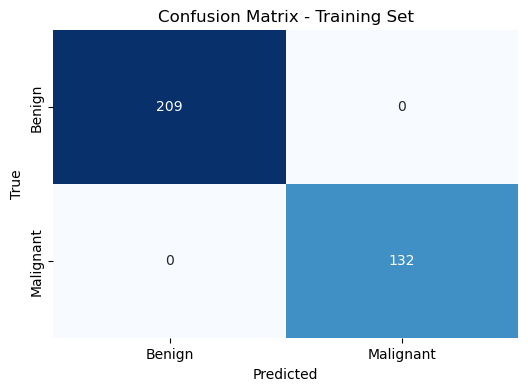

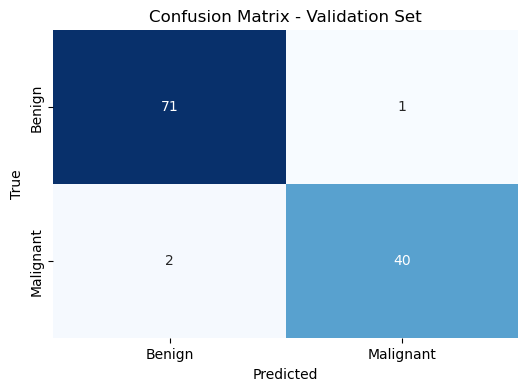

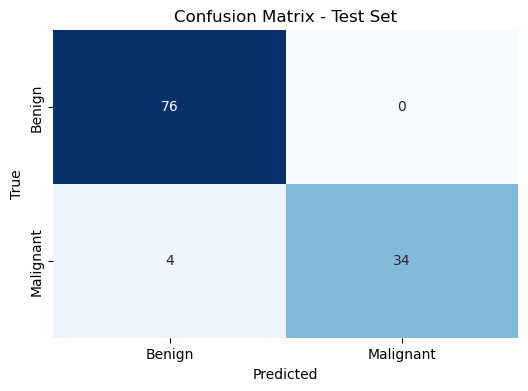

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# STEP 3: Calculate Accuracy on Training, Validation, and Test sets
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# STEP 4: Calculate Precision, Recall, and F1 Scores for Training, Validation, and Test sets
train_report = classification_report(y_train, y_train_pred, output_dict=True)
val_report = classification_report(y_val, y_val_pred, output_dict=True)
test_report = classification_report(y_test, y_test_pred, output_dict=True)

# Print Classification Reports
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))
print("Validation Classification Report:")
print(classification_report(y_val, y_val_pred))
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred))

#Create Confusion Matrix after Training, Validation, and Testing
train_cm = confusion_matrix(y_train, y_train_pred)
val_cm = confusion_matrix(y_val, y_val_pred)
test_cm = confusion_matrix(y_test, y_test_pred)

# Plot Confusion Matrices
def plot_confusion_matrix(cm, dataset_name):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, 
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    plt.title(f'Confusion Matrix - {dataset_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Plot Confusion Matrices for each dataset
plot_confusion_matrix(train_cm, 'Training Set')
plot_confusion_matrix(val_cm, 'Validation Set')
plot_confusion_matrix(test_cm, 'Test Set')


Training FPR: 0.00, Training TNR: 1.00
Validation FPR: 0.00, Validation TNR: 1.00
Test FPR: 0.00, Test TNR: 1.00


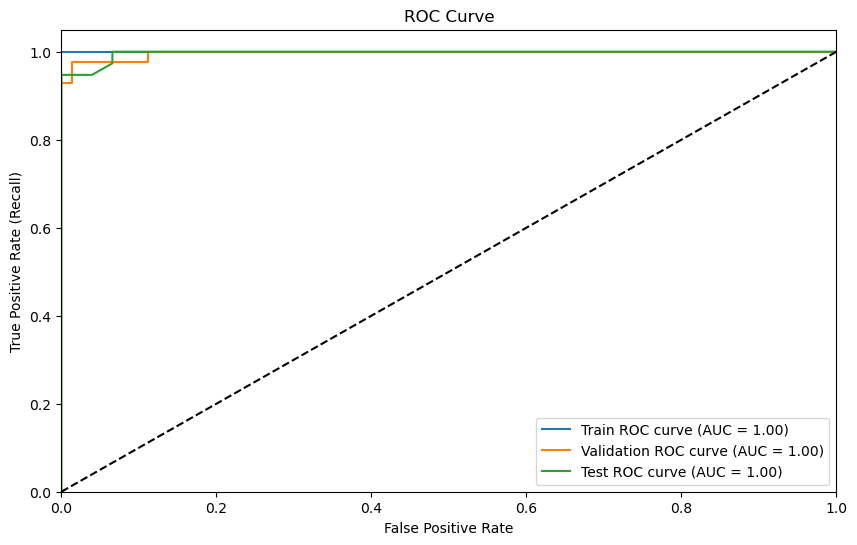

In [5]:
from sklearn.metrics import roc_curve, auc

# STEP 5
# Predict probabilities for the positive class (class 1)
y_train_prob = model.predict_proba(X_train)[:, 1]  # Probabilities for class 1
y_val_prob = model.predict_proba(X_val)[:, 1]      # Probabilities for class 1
y_test_prob = model.predict_proba(X_test)[:, 1]    # Probabilities for class 1

#Calculate ROC curve (FPR, TPR) for each set
train_fpr, train_tpr, _ = roc_curve(y_train, y_train_prob)
val_fpr, val_tpr, _ = roc_curve(y_val, y_val_prob)
test_fpr, test_tpr, _ = roc_curve(y_test, y_test_prob)

# Calculate AUC (Area Under the Curve) for each set
train_auc = auc(train_fpr, train_tpr)
val_auc = auc(val_fpr, val_tpr)
test_auc = auc(test_fpr, test_tpr)

#Calculate FPR and TNR (True Negative Rate) for each set
train_tnr = 1 - train_fpr  # TNR = 1 - FPR
val_tnr = 1 - val_fpr      # TNR = 1 - FPR
test_tnr = 1 - test_fpr    # TNR = 1 - FPR

# Display FPR and TNR for each set
print(f"Training FPR: {train_fpr[1]:.2f}, Training TNR: {train_tnr[1]:.2f}")
print(f"Validation FPR: {val_fpr[1]:.2f}, Validation TNR: {val_tnr[1]:.2f}")
print(f"Test FPR: {test_fpr[1]:.2f}, Test TNR: {test_tnr[1]:.2f}")

#Plot the ROC curves for Training, Validation, and Test sets
plt.figure(figsize=(10, 6))
plt.plot(train_fpr, train_tpr, label=f'Train ROC curve (AUC = {train_auc:.2f})')
plt.plot(val_fpr, val_tpr, label=f'Validation ROC curve (AUC = {val_auc:.2f})')
plt.plot(test_fpr, test_tpr, label=f'Test ROC curve (AUC = {test_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Random classifier (diagonal line)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()
